# Visualización y informes

Todo lo que un run produce vive en su directorio (`.soma/runs/<run_id>/`);
todo lo de este notebook son *lectores* de esos ficheros. Tres capas:
lectores/agregación (Rust, `RunView`), overlays sobre el grafo
(mermaid/graphviz anotados) y figuras Plotly (`soma.viz`, extra
`pip install 'somatize[viz]'`).

In [1]:
import json, pathlib

import plotly.io as pio

import soma

# PNG estático (kaleido): las figuras se ven en cualquier visor, GitHub
# incluido. Para interactividad (zoom/hover), comenta esta línea y abre
# el notebook en Jupyter/VS Code.
pio.renderers.default = "png"
from soma import Filter, Graph, Study, search


class Scaler(Filter):
    _cache_version = "nb07-scaler-v1"

    def fit(self, x, y=None):
        return {"mean": sum(x) / len(x)}

    def forward(self, x, state):
        return [v - state["mean"] for v in x]


class Model(Filter):
    _cache_version = "nb07-model-v1"

    def fit(self, x, y=None):
        return {"w": 0.5}

    def forward(self, x, state):
        return [v * state["w"] for v in x]


g = Graph()
g.node("scaler", Scaler())
g.node("model", Model())
g.connect("scaler", "model")

with g.track_run("nb07-fit", kind="fit", tags=["demo"]) as run:
    g.fit([1.0, 2.0, 3.0, 4.0])
    for step in range(6):
        run.log("loss", 1.0 / (step + 1), step=step)
        run.log("val_f1", 0.6 + 0.06 * step, step=step)

run.id

'run_20260730T082328_7aec'

## Listar e inspeccionar runs

`soma.runs()` escanea `<root>/runs/` (más reciente primero). Un run
`running` con heartbeat caducado se reporta como `crashed`. Cada
`RunView` agrega el log de eventos en formas listas para graficar.

In [2]:
for r in soma.runs():
    print(f"{r.id:32s} {r.kind:6s} {r.state:10s} {r.name}")

view = soma.runs()[0]
view.node_timings()

run_20260730T082328_7aec         fit    completed  nb07-fit


[{'node_id': 'scaler',
  'started_ts': '2026-07-30T08:23:28.050612339Z',
  'finished_ts': '2026-07-30T08:23:28.051785900Z',
  'duration_ms': 1,
  'outcome': 'completed',
  'cache_tier': None,
  'error': None},
 {'node_id': 'model',
  'started_ts': '2026-07-30T08:23:28.051882100Z',
  'finished_ts': '2026-07-30T08:23:28.052826119Z',
  'duration_ms': 0,
  'outcome': 'completed',
  'cache_tier': None,
  'error': None}]

In [3]:
view.cache_activity(), view.metric_series("val_f1")[:2]

({'hits': 0, 'misses': 0, 'by_node': {}},
 [{'ts': '2026-07-30T08:23:28.053106179Z',
   'name': 'val_f1',
   'value': 0.6,
   'step': 0,
   'trial_id': None,
   'node_id': None},
  {'ts': '2026-07-30T08:23:28.053312168Z',
   'name': 'val_f1',
   'value': 0.6599999999999999,
   'step': 1,
   'trial_id': None,
   'node_id': None}])

## Arquitectura anotada

El mermaid del grafo con el overlay del run: duración por nodo, hits de
caché y flags de salud, con clases de estado (`soma_completed`,
`soma_cached`, `soma_failed`, `soma_flagged`). Pégalo en mermaid.live o
míralo renderizado en `soma report`.

In [4]:
print(view.to_mermaid())

graph LR
    scaler["scaler<br/>1ms"]
    model["model<br/>0ms"]
    scaler --> model
    classDef soma_completed fill:#e8f5e9,stroke:#2e7d32,color:#1b5e20;
    class scaler soma_completed
    class model soma_completed



## Figuras

Métodos instalados sobre `RunView`; devuelven figuras Plotly
interactivas (requieren el extra `somatize[viz]`).

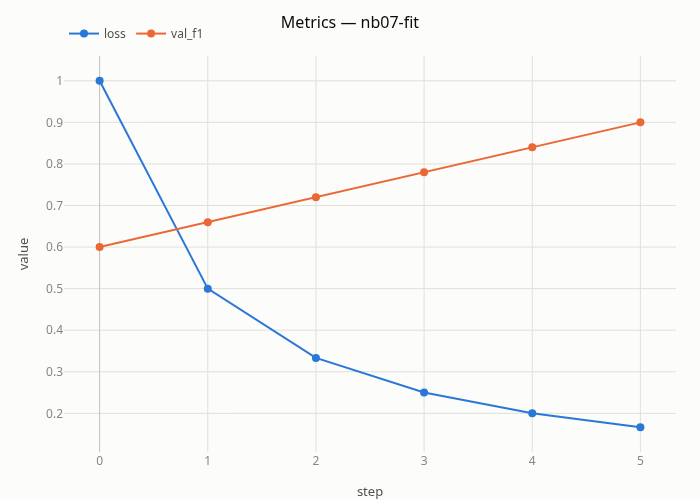

In [5]:
view.plot_metrics()

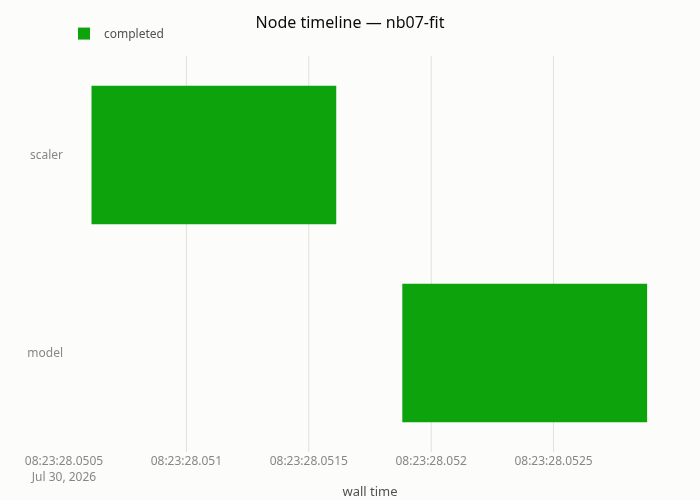

In [6]:
view.plot_gantt()  # dónde se fue el tiempo de pared, nodo a nodo

## Optimización estilo Optuna

Un `Study` es también un run (su run-dir tiene `study.json`); las
figuras llevan los nombres de Optuna para no sorprender a nadie.

In [7]:
def objective(trial):
    for step in range(5):
        f1 = 0.5 + 0.35 * trial["lr"] ** 0.2 * (step + 1) / 5
        if trial.report("f1", f1, step):
            return None
    return None


study = Study(
    "nb07-hpo",
    search_space=[
        {"type": "float", "name": "lr", "low": 1e-4, "high": 1e-1, "scale": "log"},
        {"type": "float", "name": "dropout", "low": 0.0, "high": 0.5},
    ],
    strategy="bayesian",
    n_trials=8,
    objectives=[("f1", "maximize")],
    pruning=("median", 2),
    seed=42,
)
study.run(objective)
study.best_trial["id"], study.best_trial["metrics"]

('trial_0006', {'f1': 0.6971705694400159})

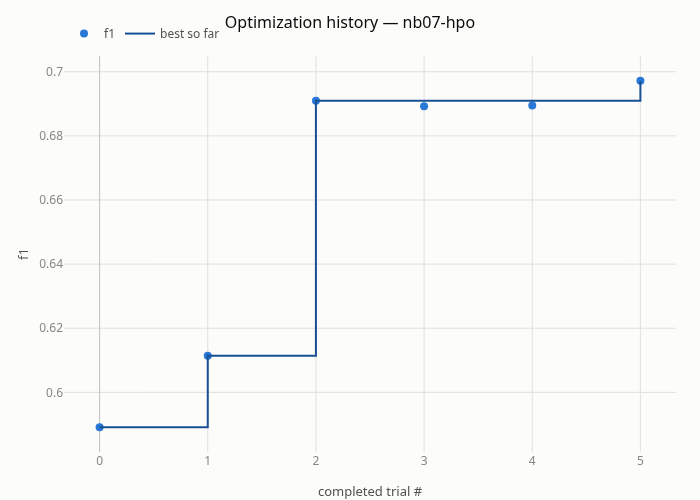

In [8]:
study.plot_optimization_history()

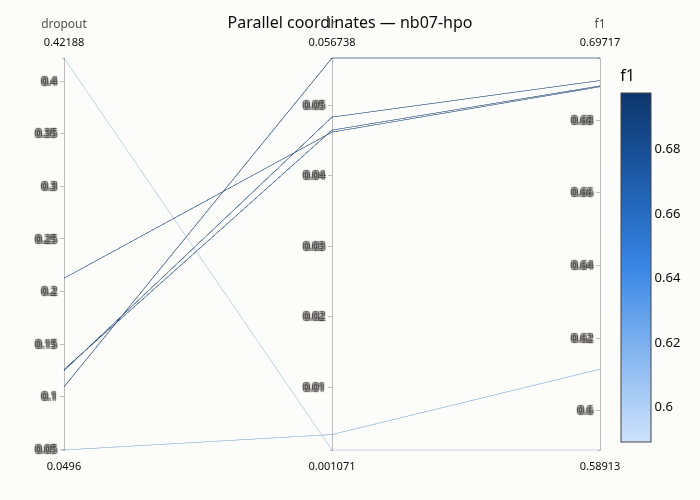

In [9]:
study.plot_parallel_coordinate()

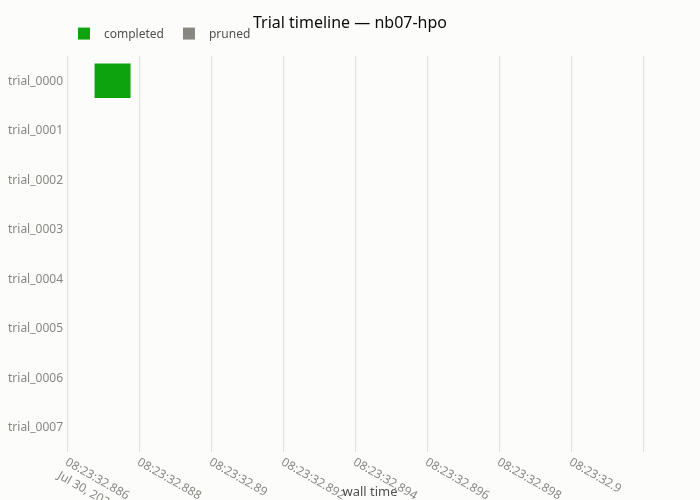

In [10]:
study.plot_timeline()

In [11]:
study.trials_dataframe().head()

,trial_id,state,started_at,finished_at,duration_ms,param_lr,param_dropout,metric_f1
0,trial_0000,completed,2026-07-30 08:23:32.886748747+00:00,2026-07-30 08:23:32.888273777+00:00,1,0.001071,0.421878,0.589134
1,trial_0001,completed,2026-07-30 08:23:32.889573442+00:00,2026-07-30 08:23:32.890523782+00:00,0,0.003266,0.049605,0.611397
2,trial_0002,completed,2026-07-30 08:23:32.891456005+00:00,2026-07-30 08:23:32.892343240+00:00,0,0.048341,0.125046,0.690955
3,trial_0003,pruned,2026-07-30 08:23:32.893387455+00:00,2026-07-30 08:23:32.893933541+00:00,0,0.000259,0.303276,0.540271
4,trial_0004,completed,2026-07-30 08:23:32.895055683+00:00,2026-07-30 08:23:32.895843235+00:00,0,0.046212,0.212712,0.689243


## Informe HTML

Un fichero autocontenido por run: DAG anotado, tiles de eficiencia,
curvas, sección HPO con tabla de trials y sección de salud. Desde la
CLI: `soma report <run_id>` (`--inline` embebe plotly.js para verlo sin
red). Los blobs `<script id="soma-data-*">` embebidos son el contrato
que leerá la futura GUI.

In [12]:
html = study.to_html(path="nb07_report.html")
print(f"nb07_report.html: {len(html) / 1024:.0f} KiB")
print("secciones:", [s.split("</h2>")[0] for s in html.split("<h2>")[1:]])

nb07_report.html: 30 KiB
secciones: ['Efficiency', 'Metrics', 'Optimization', 'Trials', 'Health']
